In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not available")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
!pip install -q ultralytics kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.8 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

import ultralytics

print("Ultralytics version:", ultralytics.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics version: 8.4.132


In [ ]:
import kagglehub

pest_path = kagglehub.dataset_download(
    "rupankarmajumdar/crop-pests-dataset"
)

print("AgroPest-12 path:")
print(pest_path)

100%|██████████| 537M/537M [00:07<00:00, 71.6MB/s]

Extracting files...


AgroPest-12 path:
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2


In [ ]:
import os

print("Dataset contents:\n")

for root, dirs, files in os.walk(pest_path):

    level = root.replace(pest_path, "").count(os.sep)

    if level > 3:
        continue

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

Dataset contents:

2/
    data.yaml
    test/
        labels/
            ants-218-_jpg.rf.e91fe697060eae1325eafc80c7351cc2.txt
            Weevil-57-_jpg.rf.db6c605d2c4d9a7cf01131a9ff8d3ab5.txt
            catterpillar-123-_jpg.rf.da95c1a2a153bd9d1a67863212cb0521.txt
            bees-2-_jpg.rf.b50421ee1660d323c49bf661187f4587.txt
            moth-59-_jpg.rf.a2096371ddb668fc2d97c60c71f40c0c.txt
            bees-234-_jpg.rf.380d39ffd0f4e18f586e6ef8445be09f.txt
            ants-138-_jpg.rf.1910f63385ebe674083ac928462bdc44.txt
            snail-21-_jpg.rf.16131718b0d135e4e508d43492391f6c.txt
            earthworms-230-_jpg.rf.21f8643d1611506137cdd74e1f22b6c7.txt
            ants-455-_jpg.rf.ef4e908c79575f5e0d089d71e471a18a.txt
        images/
            bees-289-_jpg.rf.006641aedfbe5165991fb5c014707b68.jpg
            earwig-18-_jpg.rf.d58d217588833582ca9971815aa0b202.jpg
            beetle-25-_jpg.rf.6d385355563d153c53a094b5244b9b36.jpg
            ants-122-_jpg.rf.4819e9d7a1531a8b3a430

In [ ]:
from pathlib import Path

pest_root = Path(pest_path)

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".JPG",
    ".JPEG",
    ".PNG"
}

label_extensions = {
    ".txt"
}

image_files = [
    p for p in pest_root.rglob("*")
    if p.is_file() and p.suffix in image_extensions
]

label_files = [
    p for p in pest_root.rglob("*")
    if p.is_file() and p.suffix.lower() == ".txt"
]

print("Total images:", len(image_files))
print("Total TXT files:", len(label_files))

Total images: 13143
Total TXT files: 13143


In [ ]:
print("\nFirst 20 image paths:")

for p in image_files[:20]:
    print(p)

print("\nFirst 20 label paths:")

for p in label_files[:20]:
    print(p)


First 20 image paths:
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/images/Weevil-262-_jpg.rf.86444c7a1189b7f36ee21d56940d7dee.jpg
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/images/grasshopper-332-_jpg.rf.9caf0262f9e1144707296277a8c6d953.jpg
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/images/catterpillar-294-_jpg.rf.6d8c1073e1faa83e064b6d7fa8fe9ccd.jpg
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/images/earwig-15-_jpg.rf.034c52444c0c7c544b4e9cc4e53a9d78.jpg
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/images/earwig-98-_jpg.rf.16a566989e337e894e6bd918a9873630.jpg
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/images/grasshopper-406-_jpg.rf.901e64775c1d49a0b476cca048493b70.jpg
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/version

In [ ]:
yaml_files = list(
    pest_root.rglob("*.yaml")
) + list(
    pest_root.rglob("*.yml")
)

print("YAML files found:", len(yaml_files))

for yaml_file in yaml_files:
    print(yaml_file)

YAML files found: 1
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/data.yaml


In [ ]:
import yaml

data_yaml = yaml_files[0]

with open(data_yaml, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 12, 'names': ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']}


In [ ]:
print("Number of classes:")

if "nc" in data_config:
    print(data_config["nc"])

print("\nClass names:")

if "names" in data_config:
    for i, name in enumerate(data_config["names"]):
        print(i, "→", name)

Number of classes:
12

Class names:
0 → Ants
1 → Bees
2 → Beetles
3 → Caterpillars
4 → Earthworms
5 → Earwigs
6 → Grasshoppers
7 → Moths
8 → Slugs
9 → Snails
10 → Wasps
11 → Weevils


In [ ]:
if label_files:

    sample_label = label_files[0]

    print("Sample label:")
    print(sample_label)

    with open(sample_label, "r") as f:
        print(f.read())

Sample label:
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/labels/beetle-89-_jpg.rf.a076bf8591c80248286192f1165dc7ae.txt
2 0.53828125 0.49453125 0.2671875 0.45234375


In [ ]:
print("Total images:", len(image_files))
print("Total TXT files:", len(label_files))
print("YAML files:", yaml_files)

Total images: 13143
Total TXT files: 13143
YAML files: [PosixPath('/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/data.yaml')]


In [ ]:
# Step 11: Read YOLO dataset configuration

import yaml

data_yaml = yaml_files[0]

with open(data_yaml, "r") as f:
    data_config = yaml.safe_load(f)

print("========== DATASET CONFIG ==========")

for key, value in data_config.items():
    print(f"{key}: {value}")

========== DATASET CONFIG ==========
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 12
names: ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']


In [ ]:
# Step 12: Display pest classes

class_names_pest = data_config["names"]

print("Number of pest classes:", len(class_names_pest))

print("\nPest classes:")

for i, name in enumerate(class_names_pest):
    print(f"{i:02d} → {name}")

Number of pest classes: 12

Pest classes:
00 → Ants
01 → Bees
02 → Beetles
03 → Caterpillars
04 → Earthworms
05 → Earwigs
06 → Grasshoppers
07 → Moths
08 → Slugs
09 → Snails
10 → Wasps
11 → Weevils


In [ ]:
# Step 13: Check YOLO dataset paths

print("Train path:")
print(data_config.get("train"))

print("\nValidation path:")
print(data_config.get("val"))

print("\nTest path:")
print(data_config.get("test"))

Train path:
../train/images

Validation path:
../valid/images

Test path:
../test/images


In [ ]:
# Step 14: Verify dataset directories

from pathlib import Path

dataset_root = Path(pest_path)

print("Dataset root:")
print(dataset_root)

print("\nDirectories:")

for folder in dataset_root.rglob("*"):
    if folder.is_dir():
        print(folder)

Dataset root:
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2

Directories:
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/test
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/train
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/test/labels
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/test/images
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/train/labels
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/train/images
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/labels
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/images


In [ ]:
# Step 15: Validate YOLO annotation format

invalid_labels = []
valid_labels = 0
total_annotations = 0

for label_file in label_files:

    try:

        with open(label_file, "r") as f:
            lines = f.readlines()

        for line in lines:

            line = line.strip()

            if not line:
                continue

            parts = line.split()

            # YOLO format should contain 5 values
            if len(parts) != 5:
                invalid_labels.append(
                    (str(label_file), line)
                )
                continue

            class_id, x, y, width, height = map(
                float,
                parts
            )

            # Check class ID
            if int(class_id) < 0 or int(class_id) >= len(class_names_pest):
                invalid_labels.append(
                    (str(label_file), line)
                )
                continue

            # Bounding box values should be 0-1
            if not (
                0 <= x <= 1 and
                0 <= y <= 1 and
                0 < width <= 1 and
                0 < height <= 1
            ):
                invalid_labels.append(
                    (str(label_file), line)
                )
                continue

            total_annotations += 1

        valid_labels += 1

    except Exception as e:

        invalid_labels.append(
            (str(label_file), str(e))
        )


print("================================")
print("YOLO LABEL VALIDATION")
print("================================")

print("Label files checked:", len(label_files))
print("Valid label files:", valid_labels)
print("Total annotations:", total_annotations)
print("Invalid entries:", len(invalid_labels))

YOLO LABEL VALIDATION
Label files checked: 13143
Valid label files: 13143
Total annotations: 17312
Invalid entries: 0


In [ ]:
# Step 16: Pest class distribution

from collections import Counter

pest_distribution = Counter()

for label_file in label_files:

    with open(label_file, "r") as f:

        for line in f:

            line = line.strip()

            if not line:
                continue

            class_id = int(
                line.split()[0]
            )

            pest_distribution[class_id] += 1


print("Pest annotation distribution:\n")

for class_id in range(len(class_names_pest)):

    count = pest_distribution[class_id]

    print(
        f"{class_id:02d} | "
        f"{class_names_pest[class_id]:30s} | "
        f"{count} annotations"
    )

Pest annotation distribution:

00 | Ants                           | 2496 annotations
01 | Bees                           | 1750 annotations
02 | Beetles                        | 1202 annotations
03 | Caterpillars                   | 1972 annotations
04 | Earthworms                     | 1195 annotations
05 | Earwigs                        | 1359 annotations
06 | Grasshoppers                   | 1228 annotations
07 | Moths                          | 1210 annotations
08 | Slugs                          | 1060 annotations
09 | Snails                         | 1356 annotations
10 | Wasps                          | 1346 annotations
11 | Weevils                        | 1138 annotations


In [ ]:
# Step 17: Find an image with annotations

from PIL import Image
import matplotlib.pyplot as plt

sample_label = None

for label_file in label_files:

    with open(label_file, "r") as f:
        content = f.read().strip()

    if content:
        sample_label = label_file
        break

print("Sample label:")
print(sample_label)

Sample label:
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/labels/beetle-89-_jpg.rf.a076bf8591c80248286192f1165dc7ae.txt


In [ ]:
# Find corresponding image

image_stem = sample_label.stem

matching_images = [
    img for img in image_files
    if img.stem == image_stem
]

print("Matching images:", matching_images[:5])

Matching images: [PosixPath('/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/valid/images/beetle-89-_jpg.rf.a076bf8591c80248286192f1165dc7ae.jpg')]


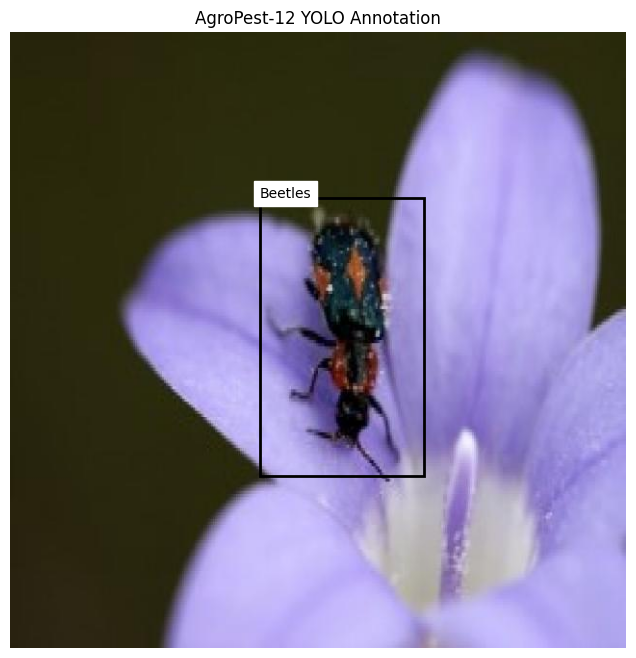

In [ ]:
# Display image with YOLO bounding boxes

image_path = matching_images[0]

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(10, 8))
plt.imshow(image)

img_width, img_height = image.size

with open(sample_label, "r") as f:

    for line in f:

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        class_id, x, y, width, height = map(
            float,
            parts
        )

        # Convert YOLO coordinates to pixel coordinates
        box_width = width * img_width
        box_height = height * img_height

        center_x = x * img_width
        center_y = y * img_height

        left = center_x - box_width / 2
        top = center_y - box_height / 2

        rectangle = plt.Rectangle(
            (left, top),
            box_width,
            box_height,
            fill=False,
            linewidth=2
        )

        plt.gca().add_patch(rectangle)

        plt.text(
            left,
            top,
            class_names_pest[int(class_id)],
            fontsize=10,
            backgroundcolor="white"
        )

plt.axis("off")
plt.title("AgroPest-12 YOLO Annotation")
plt.show()

In [ ]:
# Step 18: Prepare YOLO dataset configuration

from pathlib import Path
import yaml
import os

data_yaml = Path(yaml_files[0])

print("Original YAML:")
print(data_yaml)

with open(data_yaml, "r") as f:
    data_config = yaml.safe_load(f)

print("\nDataset configuration:")
for key, value in data_config.items():
    print(f"{key}: {value}")

Original YAML:
/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/data.yaml

Dataset configuration:
train: ../train/images
val: ../valid/images
test: ../test/images
nc: 12
names: ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']


In [ ]:
# Step 19: Verify YOLO configuration

print("Classes:", data_config["names"])
print("Number of classes:", len(data_config["names"]))

assert len(data_config["names"]) == 12, \
    "Expected 12 pest classes."

print("\n✅ 12 pest classes confirmed.")

Classes: ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils']
Number of classes: 12

✅ 12 pest classes confirmed.


In [ ]:
# Check whether configured paths exist

yaml_directory = data_yaml.parent

for key in ["train", "val", "test"]:

    if key in data_config:

        configured_path = Path(
            data_config[key]
        )

        if not configured_path.is_absolute():
            configured_path = yaml_directory / configured_path

        print(
            f"{key}: {configured_path}"
        )

        print(
            "Exists:",
            configured_path.exists()
        )

train: /root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/../train/images
Exists: False
val: /root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/../valid/images
Exists: False
test: /root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2/../test/images
Exists: False


In [ ]:
# Step 20: Create CROPORA YOLO configuration

cropora_yaml = "/content/cropora_pest.yaml"

config = {
    "path": str(pest_root),
    "train": data_config["train"],
    "val": data_config["val"],
    "names": data_config["names"]
}

if "test" in data_config:
    config["test"] = data_config["test"]

with open(cropora_yaml, "w") as f:
    yaml.dump(
        config,
        f,
        sort_keys=False
    )

print("CROPORA YOLO configuration:")
print(cropora_yaml)

print("\nConfiguration:")
print(config)

CROPORA YOLO configuration:
/content/cropora_pest.yaml

Configuration:
{'path': '/root/.cache/kagglehub/datasets/rupankarmajumdar/crop-pests-dataset/versions/2', 'train': '../train/images', 'val': '../valid/images', 'names': ['Ants', 'Bees', 'Beetles', 'Caterpillars', 'Earthworms', 'Earwigs', 'Grasshoppers', 'Moths', 'Slugs', 'Snails', 'Wasps', 'Weevils'], 'test': '../test/images'}


In [ ]:
# Step 21: Load YOLO11 Nano

from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("✅ YOLO11n loaded successfully.")

✅ YOLO11n loaded successfully.


In [ ]:
# Step 22: Train CROPORA Pest Detection Model

results = model.train(
    data=cropora_yaml,

    epochs=50,

    imgsz=640,

    batch=16,

    device=0,

    workers=2,

    patience=10,

    optimizer="auto",

    pretrained=True,

    project="/content/CROPORA_Pest_Training",

    name="YOLO11n_AgroPest12",

    exist_ok=True,

    verbose=True
)

Ultralytics 8.4.132 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cropora_pest.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11n_AgroPest12, nbs=64, nms=Fal

KeyboardInterrupt: 